In [1]:
import os
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/dataset')
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/')
from dataset.dataset_utils import *
from model.ES_net_mixer import *
from model import LightingModel
from torch.utils.data import DataLoader
import torch.nn.functional as F
import lightning as L
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
from inference_utils import *

In [2]:
train_dataset, val_dataset= get_dataset(
        data_dir="/home/linhang/workbench/Earthquake_data/",
        window_size=140,
        forecast_horizon=14,
        lape_dim=30,
        geo_percentage=0.3,
        sem_percentage=0.3,
        time_resolution=14,
        earthquake_catalog_window=1400,
        train_percentage=0.9,
        )

GNSS Data Length: 8472
Earthquake Data Length: 8472


In [3]:
for key in val_dataset[0]:
    break

In [4]:
len(train_dataset), len(val_dataset)

(7624, 848)

In [5]:
# model_dir = "/home/linhang/workbench/workbench/Earthquake_predictor/Result/"
# with open("model_params.json", 'r') as f:
#     model_par = json.load(f)
# model = LightingModel(model = ES_net_mixer, lr = None, max_epoch=None,loss_fns=None,**model_par).to("cuda:2")
# model.initial_model("Result/Pretrain_ES_net_mixer_california/checkpoints/Val-epoch=01-val_loss=0.47.ckpt").to("cuda:2")
# model.eval()
model = LightingModel.load_from_checkpoint("/home/linhang/workbench/workbench/Earthquake_predictor/Result/Pretrain_ES_net_mixer_california/checkpoints/last.ckpt",map_location=torch.device("cuda:2"))
model.eval()

LightingModel(
  (model): ES_net_mixer(
    (earthquake_embedding): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=1, out_features=128, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (location_embedding): LocationEmbedding(
        (location_embed): Linear(in_features=2, out_features=128, bias=True)
        (norm): Identity()
      )
    )
    (gnss_embedding_trend): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=4, out_features=128, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=128, bias=True)
      

In [6]:

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True, collate_fn=train_dataset.collate_fn,num_workers=64
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False, collate_fn=val_dataset.collate_fn,num_workers=64
)


In [7]:
use_loader = val_loader

In [8]:
sample_batch = next(iter(use_loader))
sample_batch

with torch.no_grad():
    predictions = model.predict_step(sample_batch, 0)


In [9]:
earthquake_history_topk,earthquake_future_topk,energy_predict,topk_index = find_activate_area(sample_batch['log_energy_history'][0],predictions['log_energy_future'][0],predictions['energy_predict'][0],9)

In [10]:
earthquake_location_topk = np.round(denormalize_locations(predictions['earthquake_location'][0][topk_index]).detach().cpu().numpy(),2)

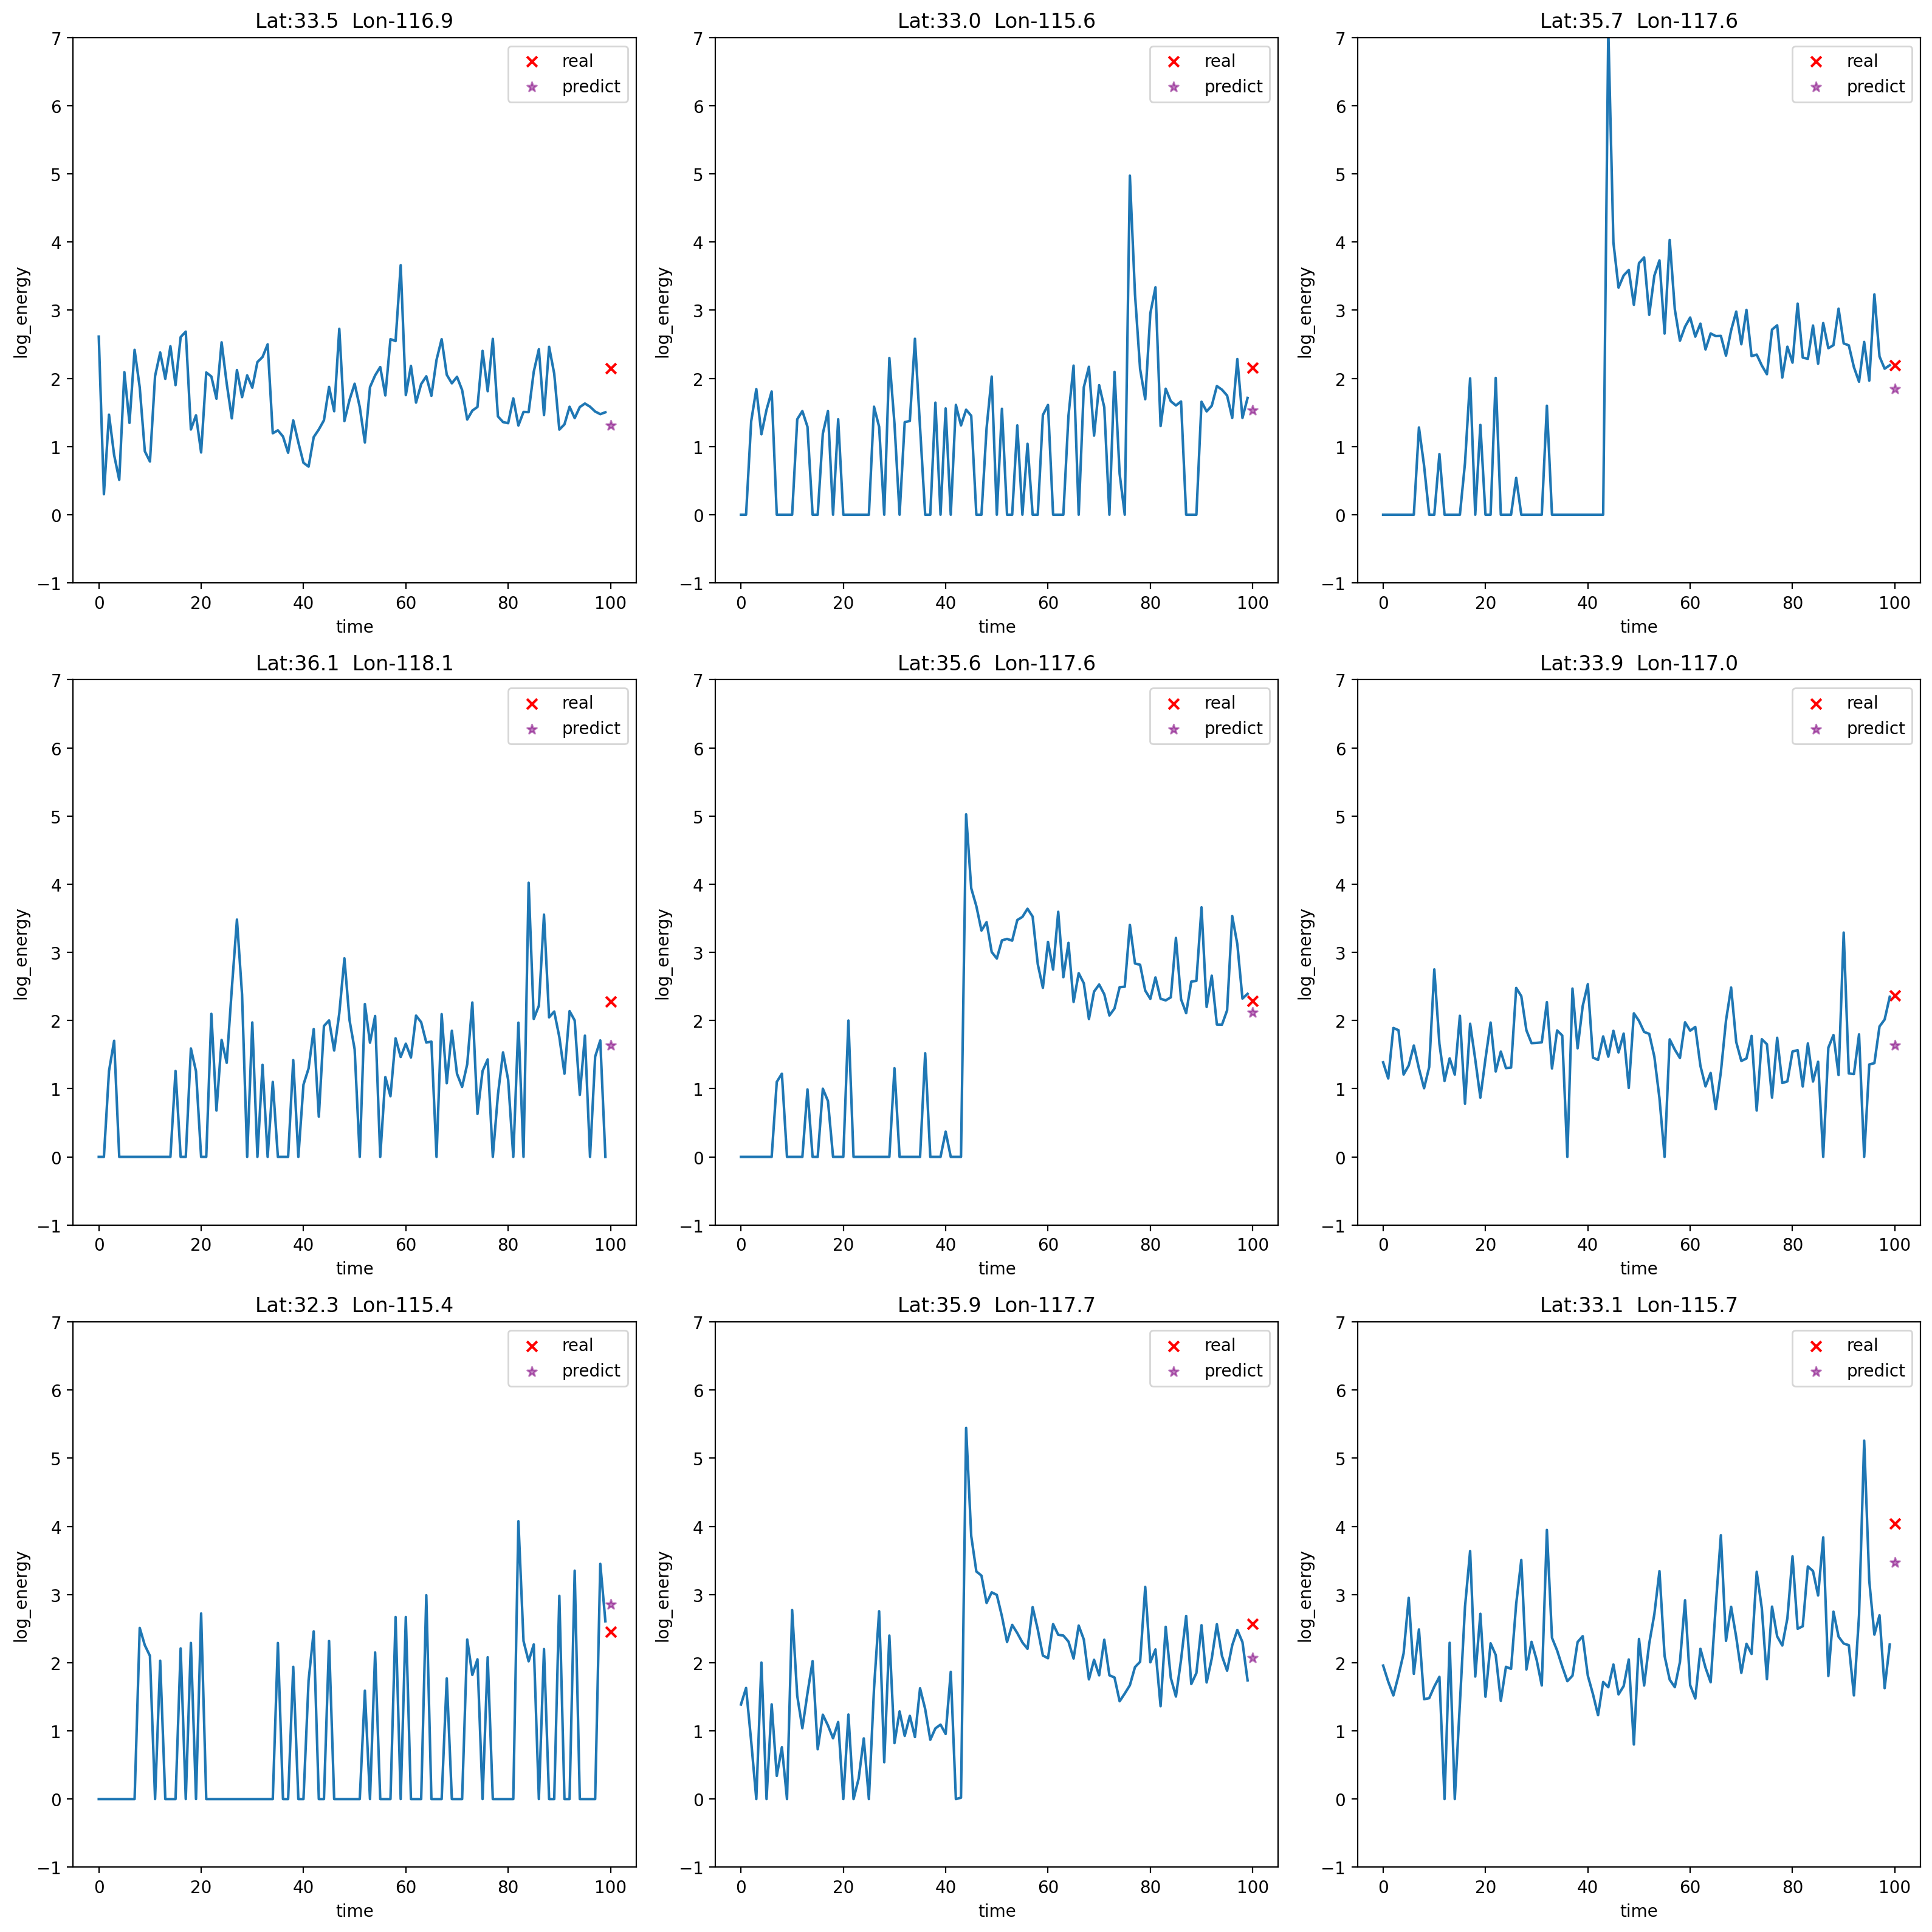

In [11]:
plt.figure(figsize=(16,16),dpi=200)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(range(len(earthquake_history_topk[:,i])),earthquake_history_topk[:,i])
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(earthquake_future_topk[:,i])),earthquake_future_topk[:,i],c='r',marker='x',label='real')
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(energy_predict[:,i])),energy_predict[:,i],c='purple',marker='*',label='predict',alpha=0.5)
    plt.title('Lat:'+str(earthquake_location_topk[i][0])+'  Lon'+str(earthquake_location_topk[i][1]))
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('log_energy')
    plt.ylim(-1,7)
plt.tight_layout()
plt.show()

In [12]:
energy_predict_all = []
earthquake_future_all = []
energy_history_all = []
earthquake_happen_all = []
with torch.no_grad():
    for batch in use_loader:
        predictions = model.predict_step(batch, 0)
        energy_predict_all.append(predictions['energy_predict'])
        earthquake_future_all.append(predictions['log_energy_future'])
        energy_history_all.append(batch['log_energy_history'])
        earthquake_happen_all.append(batch['earthquake_happen'])
energy_predict_all = torch.cat(energy_predict_all)
earthquake_future_all = torch.cat(earthquake_future_all)
energy_history_all = torch.cat(energy_history_all)
earthquake_happen_all = torch.cat(earthquake_happen_all)


TPR (Recall): 0.00
TNR (Specificity): 1.00
Precision: 0.00
Accuracy: 0.99
Error: 0.01
FPR: 0.00
Aggregative Score: 0.33


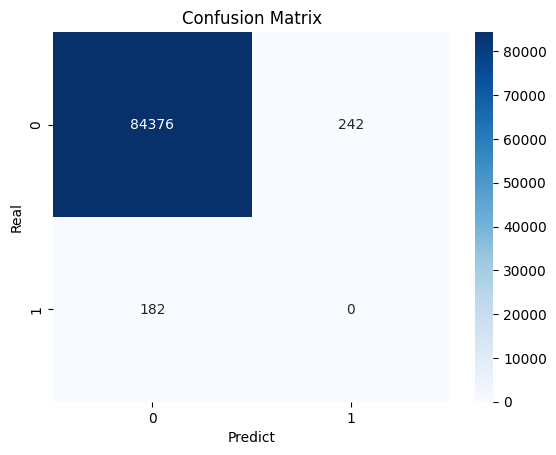

In [13]:
energy_predict,earthquake_target = plot_confusion_matrix(energy_predict_all,earthquake_future_all)

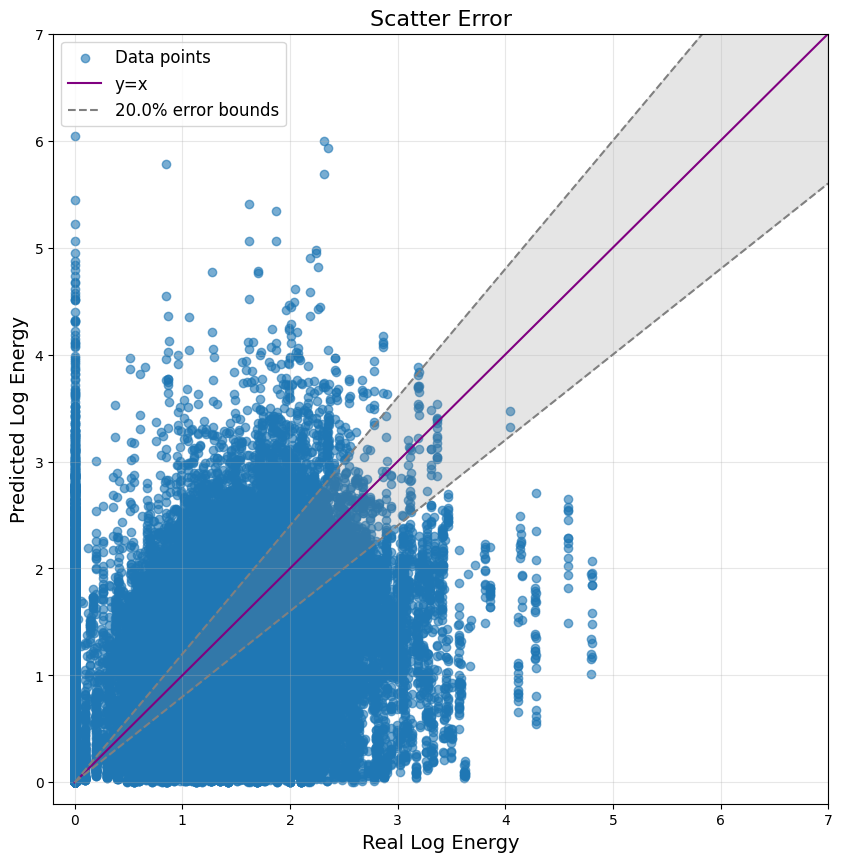

In [14]:
plot_error(energy_predict,earthquake_target,0.2)

In [15]:
energy_history_last = energy_history_all[:,-1,:,:].flatten().detach().cpu().numpy()

In [16]:
delta_energy_predict = energy_predict - energy_history_last
delta_energy_target = earthquake_target - energy_history_last

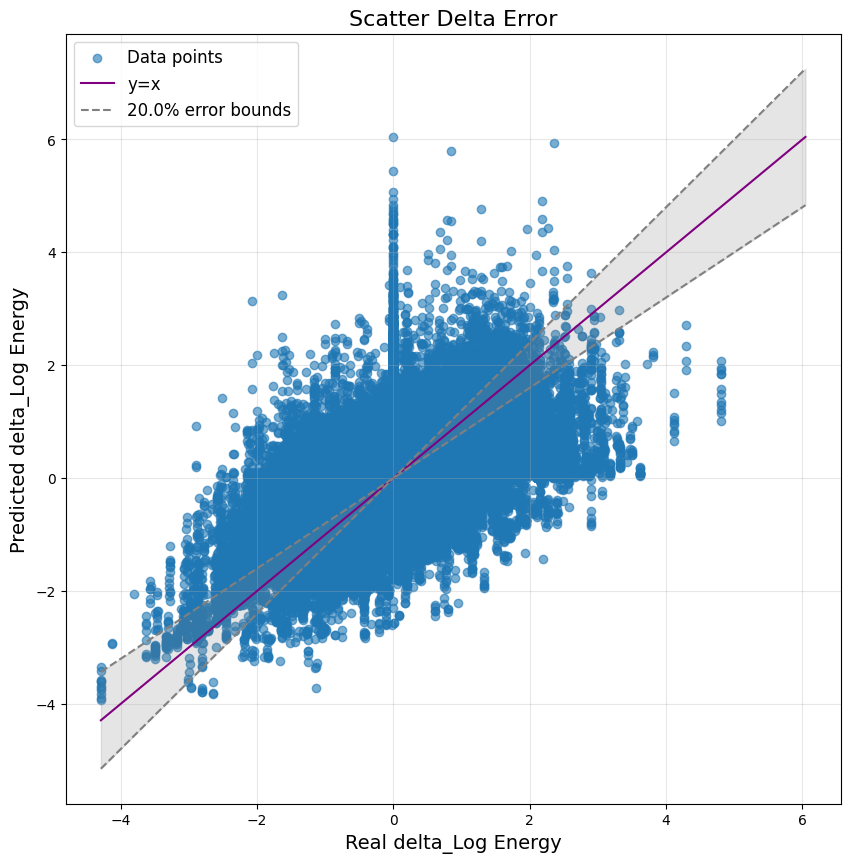

In [17]:
plot_delta_error(delta_energy_predict,delta_energy_target,0.2)

In [18]:
mse =np.power((energy_predict - earthquake_target),2).mean()
rmse = np.sqrt(mse)
print('rmse:', rmse)
print('mse:', mse)

rmse: 0.8247267
mse: 0.6801742
